---
authors:
  - name: Juniper Tyree
    orcid: 0000-0002-7923-9609
    affiliations:
      - name: University of Helsinki
        ror: 040af2s02
    github: juntyr
  - name: Peter Lindstrom
    orcid: 0000-0003-3817-4199
    affiliations:
      - name: Lawrence Livermore National Laboratory
        ror: 041nk4h53
    github: lindstro
---

# ZFP

| [![version-badge]][version-url] | [![citation-badge]][citation-url] | [![source-badge]][source-url] | [![documentation-badge]][documentation-url] | [![pitch-badge]][pitch-url] |
|:-:|:-:|:-:|:-:|:-:|

[version-badge]: https://img.shields.io/badge/v1.0.1+-grey?style=for-the-badge
[citation-badge]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white
[source-badge]: https://img.shields.io/badge/source-grey?style=for-the-badge&logo=github&logoColor=white
[documentation-badge]: https://img.shields.io/badge/documentation-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[pitch-badge]: https://img.shields.io/badge/pitch-grey?style=for-the-badge&logo=slides&logoColor=white

[version-url]: https://github.com/LLNL/zfp/tree/a59023905ade2494fb107f7c1809330b480d5e1c
[citation-url]: https://doi.org/10.1109/tvcg.2014.2346458
[source-url]: https://github.com/llnl/ZFP
[documentation-url]: https://zfp.readthedocs.io/en/release1.0.1/
[pitch-url]: https://github.com/climet-eu/egu26-compression-sc2-5/blob/1.0.0/pitches/b-zfp.pdf

ZFP [^zfp] is a high-throughput transform-based compressor for n-dimensional floating-point and integer data, which compresses the data in independent $4 \times \ldots \times 4$ blocks. The values inside a block are rescaled, decorrelated, and transformed into a bit stream that can be truncated at any point to select the desired quality.

ZFP supports several compression modes, including (1) targeting a specific compression ratio, (2) bounding the pointwise absolute error, or (3) losslessly compressing the data, and more. You can find out more about the other modes at <https://zfp.readthedocs.io/en/release1.0.1/modes.html>.

:::{tip}
ZFP pads each data dimension size to be a multiple of four. For small dimensions, this can significantly reduce the compression ratio:

- when targeting a specific compression ratio, the padding is taken into account, and a lower-than-requested compression ratio will be achieved
- when bounding the pointwise absolute error, the additional dimensions require ZFP to account for further error accumulation by conservatively reducing the actual compression error that will be produced

In such cases, it may be preferable to reshape the array such that the small dimensions are merged into a larger dimension. Alternatively, dimensions with low correlation can be compressed as independent data slices.
:::

We use ZFP v1.0.1 with the `ZFP_ROUNDING_MODE=ZFP_ROUND_FIRST` and `ZFP_WITH_TIGHT_ERROR=ON` settings, also known as ZFP-ROUND [^zfp-round][^zfp-round-stats], which produces unbiased compression errors and higher compression ratios.

[^zfp]: Lindstrom, P. (2014). Fixed-Rate Compressed Floating-Point arrays. *IEEE Transactions on Visualization and Computer Graphics*, 20(12), 2674–2683. Available from: [doi:10.1109/tvcg.2014.2346458](https://doi.org/10.1109/tvcg.2014.2346458).

[^zfp-round]: Hammerling, D. M., Baker, A. H., Pinard, A., & Lindstrom, P. (2019). A Collaborative Effort to Improve Lossy Compression Methods for Climate Data. *2019 IEEE/ACM 5th International Workshop on Data Analysis and Reduction for Big Scientific Data (DRBSD-5)*, 16–22. Available from: [doi:10.1109/drbsd-549595.2019.00008](https://doi.org/10.1109/drbsd-549595.2019.00008).

[^zfp-round-stats]: Fox, A., & Lindstrom, P. (2026). Enhancing ZFP: a statistical approach to understanding and reducing error bias in a lossy Floating-Point compression algorithm. *SIAM Journal on Scientific Computing*, 48(1), B1–B30. Available from: [doi:10.1137/24m1679586](https://doi.org/10.1137/24m1679586).

In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
import h5netcdf
import numpy as np
import xarray as xr
from upath import UPath

[pyodide]: Loading fsspec, h5netcdf, numpy, pandas, pathlib_abc, python-dateutil, pytz, six, tzdata, universal_pathlib, xarray
[pyodide]: Loaded fsspec, h5netcdf, numpy, pandas, pathlib_abc, python-dateutil, pytz, six, tzdata, universal_pathlib, xarray
[pyodide]: Loading h5py
[pyodide]: Loaded h5py
[pyodide]: Loading pyfive, typing_extensions
[pyodide]: Loaded pyfive, typing_extensions
[pyodide]: Loading pyarrow, pyodide-unix-timezones
[pyodide]: Loaded pyarrow, pyodide-unix-timezones
[pyodide]: Loading cloudpickle
[pyodide]: Loaded cloudpickle
[pyodide]: Loading Bottleneck
[pyodide]: Loaded Bottleneck
[pyodide]: Loading cftime
[pyodide]: Loaded cftime
[pyodide]: Loading PyYAML, click, dask, locket, partd, toolz
[pyodide]: Loaded PyYAML, click, dask, locket, partd, toolz
[pyodide]: Loading lz4
[pyodide]: Loaded lz4
[pyodide]: Memory usage has grown to 107.9MiB (from 43.2MiB) for this notebook
[pyodide]: Loaded 90 new dynamic libraries (93 total for this notebook)


In [3]:
# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

data = UPath(BASE_URL)

In [4]:
import earthkit.plots

from utils import open_remote_dataset, quickplot

[pyodide]: Loading Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, referencing, rpds-py, scipy, shapely, tqdm
[pyodide]: Loaded Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, refere

## Importing the `Zfp` compressor

In [5]:
from numcodecs_wasm_zfp import Zfp

[pyodide]: Loading Deprecated, leb128, numcodecs, numcodecs-combinators, numcodecs-observers, numcodecs_wasm, numcodecs_wasm_zfp, wrapt
[pyodide]: Loaded Deprecated, leb128, numcodecs, numcodecs-combinators, numcodecs-observers, numcodecs_wasm, numcodecs_wasm_zfp, wrapt
[pyodide]: Loading crc32c
[pyodide]: Loaded crc32c
[pyodide]: Loading msgpack
[pyodide]: Loaded msgpack
[pyodide]: Memory usage has grown to 155.4MiB (from 129.5MiB) for this notebook
[pyodide]: Loaded 12 new dynamic libraries (112 total for this notebook)


In [6]:
?Zfp

Init signature:
Zfp(
    mode,
    _version='0.2.0',
    max_bits=None,
    max_prec=None,
    min_bits=None,
    min_exp=None,
    non_finite='deny',
    precision=None,
    rate=None,
    tolerance=None,
)
Docstring:     
Codec providing compression using ZFP

Parameters
----------
mode : ...
     - "expert": The most general mode, which can describe all four other modes
    
     - "fixed-rate": In fixed-rate mode, each d-dimensional compressed block of `$4^d$`
        values is stored using a fixed number of bits. This number of
        compressed bits per block is amortized over the `$4^d$` values to give
        a rate of `$rate = \frac{maxbits}{4^d}$` in bits per value.
    
     - "fixed-precision": In fixed-precision mode, the number of bits used to encode a block may
        vary, but the number of bit planes (the precision) encoded for the
        transform coefficients is fixed.
    
     - "fixed-accuracy": In fixed-accuracy mode, all transform coefficient bit planes up to

## Targeting a specific compression ratio

ZFP can target a specific compression ratio using:

In [7]:
cr = 10  # x10 compression

# dtype = da.dtype
dtype = np.dtype(np.float64)  # for example

Zfp(mode="fixed-rate", rate=dtype.itemsize * 8 / cr)

Zfp(mode='fixed-rate', rate=6.4, non_finite='deny', _version='0.2.0')

## Bounding the pointwise absolute error

ZFP can bound the absolute error using:

In [8]:
eb_abs = 0.1

Zfp(mode="fixed-accuracy", tolerance=eb_abs)

Zfp(mode='fixed-accuracy', tolerance=0.1, non_finite='deny', _version='0.2.0')

It is worth noting that ZFP often produces errors that are significantly below the error bound.

## Bounding the pointwise relative error

ZFP can, with some caveats, be configured in export mode to bound the pointwise relative error [^zfp-pw]. The easiest way to bound the pointwise relative error with ZFP is to transform the relative error bound into an absolute error bound [^pwrel] using a metacompressor such as the `pw_rel_compressor_plugin` in LibPressio [^libpressio] or the `numcodecs_pw_ratio.PointwiseRatioErrorBoundedCodec` port:

[^zfp-pw]: <https://zfp.readthedocs.io/en/release1.0.1/faq.html#q-relerr>

[^pwrel]: Liang, X., Di, S., Tao, D., Chen, Z., & Cappello, F. (2018). An Efficient Transformation Scheme for Lossy Data Compression with Point-Wise Relative Error Bound. *2018 IEEE International Conference on Cluster Computing (CLUSTER)*, 179–189. Available from: [doi:10.1109/cluster.2018.00036](https://doi.org/10.1109/cluster.2018.00036).

[^libpressio]: Underwood, R., Malvoso, V., Calhoun, J. C., Di, S., & Cappello, F. (2021). Productive and Performant Generic Lossy Data Compression with LibPressio. *2021 7th International Workshop on Data Analysis and Reduction for Big Scientific Data (DRBSD-7)*, 1–10. Available from: [doi:10.1109/drbsd754563.2021.00005](https://doi.org/10.1109/drbsd754563.2021.00005).

In [9]:
from numcodecs_pw_ratio import PointwiseRatioErrorBoundedCodec
from numcodecs_wasm_zstd import Zstd

eb_rel = 0.01

PointwiseRatioErrorBoundedCodec(
    # transform pointwise relative error bound into pointwise ratio error bound
    eb_ratio=1 + eb_rel,
    # mark how the absolute error is configured
    eb_abs_marker="$eb_abs",
    # lossy compressor that will use an absolute error bound
    log_codec={
        **Zfp(mode="fixed-accuracy", tolerance=-1).get_config(),
        "tolerance": "$eb_abs",
    },
    # lossless compressor for compressing the data signs
    sign_codec=Zstd(level=3),
)

[pyodide]: Loading numcodecs-pw-ratio, numcodecs_wasm_zstd
[pyodide]: Loaded numcodecs-pw-ratio, numcodecs_wasm_zstd


PointwiseRatioErrorBoundedCodec(eb_ratio=1.01, eb_abs_marker='$eb_abs', log_codec={'id': 'zfp.rs', 'mode': 'fixed-accuracy', 'tolerance': '$eb_abs', 'non_finite': 'deny', '_version': '0.2.0'}, sign_codec=Zstd(level=3, _version='0.1.0'))

## Preserving NaN Missing Values

ZFP does not yet support preserving infinite and NaN values during lossy compression, though work on supporting special values is ongoing [^missing]. By default, the `non_finite="deny"` setting will raise an error when these values are encountered. It is also possible to pass `non_finite="allow-unsafe"` to encode data with these values, though this may cause undefined behaviour and produce incorrect values in the $4 \times \ldots \times 4$ blocks that contain non-finite values.

[^missing]: Lindstrom, P. (2025). *Supporting special values in ZFP*. Available from: [doi:10.2172/2998448](https://doi.org/10.2172/2998448).

## Example

In [10]:
# Load the data
ds = open_remote_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_levels_steps_204_216_228_240.nc",
    engine="h5netcdf",
    decode_timedelta=True,
)
da = ds["2t"]

[pyodide]: Loading ipyfilite, ipywidgets, jupyterlab_widgets
[pyodide]: Loaded ipyfilite, ipywidgets, jupyterlab_widgets
[pyodide]: Loading WebOb, beautifulsoup4, cattrs, legacy-cgi, lxml, pydap, requests-cache, soupsieve, url-normalize
[pyodide]: Loaded WebOb, beautifulsoup4, cattrs, legacy-cgi, lxml, pydap, requests-cache, soupsieve, url-normalize
[pyodide]: Loading donfig, google-crc32c, zarr
[pyodide]: Loaded donfig, google-crc32c, zarr
[pyodide]: Loading arraypartition, cfapyx
[pyodide]: Loaded arraypartition, cfapyx


/lib/python3.14/site-packages/earthkit/data/core/config.py:287: UserWarning: only soft file lock is available
  from filelock import FileLock


[pyodide]: Loading MetPy, pooch
[pyodide]: Loaded MetPy, pooch
[pyodide]: Loading uncertainties
[pyodide]: Loaded uncertainties
[pyodide]: Loading click-plugins, cligj, fiona
[pyodide]: Loaded click-plugins, cligj, fiona
[pyodide]: Loading boto3, botocore, jmespath, s3transfer
[pyodide]: Loaded boto3, botocore, jmespath, s3transfer
[pyodide]: Loading kerchunk, ujson
[pyodide]: Loaded kerchunk, ujson
[pyodide]: Memory usage has grown to 322.4MiB (from 155.4MiB) for this notebook
[pyodide]: Loaded 116 new dynamic libraries (228 total for this notebook)


In [11]:
eb_abs = 0.1  # 0.1 K

codec = Zfp(mode="fixed-accuracy", tolerance=eb_abs)

In [12]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

[pyodide]: Memory usage has grown to 464.4MiB (from 322.4MiB) for this notebook


/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


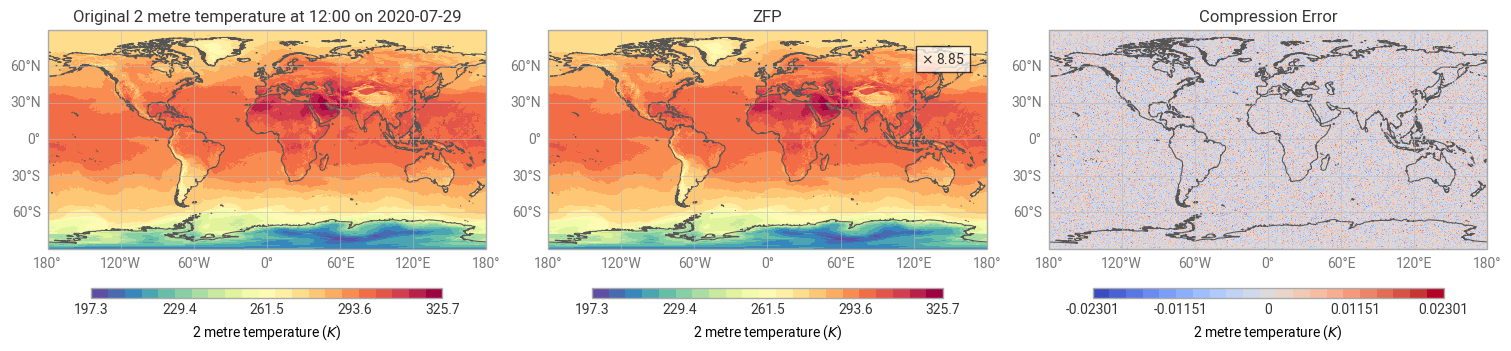

[pyodide]: Memory usage has grown to 1006.7MiB (from 464.4MiB) for this notebook
[pyodide]: Loaded 2 new dynamic libraries (230 total for this notebook)


In [13]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    figsize=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec, fig.add_map(0, 1), title="ZFP", cr=da.nbytes / np.array(da_enc).nbytes
)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()